# Transfer-Matrix Seat Simulator

Projects 2026 Hungarian parliamentary seats from 2022 district-level results
using a probabilistic voter-transfer model calibrated to the current polling nowcast.

**Approach:**
1. Collapse 2022 OEVK votes into 5 *source blocs* per district
2. Define a national transfer matrix (source → 2026 target) with Dirichlet priors
3. Calibrate it so national aggregates match `nowcast_latest.json`
4. Add district-level logistic-normal deviations
5. Monte Carlo: sample district votes → OEVK winners → győzteskompenzáció → d'Hondt list seats

In [15]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import softmax, log_softmax
from scipy.optimize import minimize

from seats import load_2022_baseline, seat_calculator, FIDESZ, EEGY, SHORT_NAMES

rng = np.random.default_rng(2026)

plt.rcParams.update({
    'figure.figsize': (14, 7),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

## 1. Load 2022 baseline & collapse into source blocs

In [16]:
baseline = load_2022_baseline()

SOURCES = ["Fidesz22", "Opp22", "MH22", "MKKP22", "Other22"]
TARGETS = ["Fidesz26", "TISZA26", "Bal26", "MH26", "MKKP26", "Other26", "Abstain26"]

S = len(SOURCES)
T = len(TARGETS)

MH_FULL = "MI HAZÁNK MOZGALOM"
MKKP_FULL = "MAGYAR KÉTFARKÚ KUTYA PÁRT"

def classify_2022(party_name: str) -> str:
    if party_name == FIDESZ:
        return "Fidesz22"
    elif party_name == EEGY:
        return "Opp22"
    elif party_name == MH_FULL:
        return "MH22"
    elif party_name == MKKP_FULL:
        return "MKKP22"
    else:
        return "Other22"

districts = sorted(baseline["oevk_votes"].keys())
D = len(districts)

# V22[d, s] = votes in district d for source bloc s
V22 = np.zeros((D, S), dtype=np.float64)

for i, dist in enumerate(districts):
    for party, votes in baseline["oevk_votes"][dist].items():
        src = classify_2022(party)
        j = SOURCES.index(src)
        V22[i, j] += votes

print(f"Districts: {D}")
print(f"Source blocs: {SOURCES}")
print(f"Target blocs: {TARGETS}")
print(f"\nNational 2022 source totals:")
for j, src in enumerate(SOURCES):
    print(f"  {src:<12s} {V22[:, j].sum():>12,.0f}  ({V22[:, j].sum() / V22.sum() * 100:.1f}%)")
print(f"  {'TOTAL':<12s} {V22.sum():>12,.0f}")

Districts: 106
Source blocs: ['Fidesz22', 'Opp22', 'MH22', 'MKKP22', 'Other22']
Target blocs: ['Fidesz26', 'TISZA26', 'Bal26', 'MH26', 'MKKP26', 'Other26', 'Abstain26']

National 2022 source totals:
  Fidesz22        2,823,419  (52.5%)
  Opp22           1,983,708  (36.9%)
  MH22              307,064  (5.7%)
  MKKP22            126,648  (2.4%)
  Other22           134,849  (2.5%)
  TOTAL           5,375,688


## 2. Load nowcast targets

In [17]:
with open("nowcast_latest.json", encoding="utf-8") as f:
    nowcast = json.load(f)

# Nowcast gives shares among decided voters (excluding abstainers).
# Map nowcast keys to our target names.
NOWCAST_MAP = {
    "Fidesz": "Fidesz26",
    "TISZA": "TISZA26",
    "Bal": "Bal26",
    "MH": "MH26",
    "MKKP": "MKKP26",
    "EM": "Other26",
}

nowcast_shares = {}  # target → share (0-1) among decided voters
for poll_key, target in NOWCAST_MAP.items():
    if poll_key in nowcast["estimates"]:
        nowcast_shares[target] = nowcast["estimates"][poll_key]["point"] / 100.0

# Nowcast uncertainty (80% CI half-width) for weighting
nowcast_se = {}
for poll_key, target in NOWCAST_MAP.items():
    if poll_key in nowcast["estimates"]:
        e = nowcast["estimates"][poll_key]
        nowcast_se[target] = (e["hi80"] - e["lo80"]) / 2.0 / 100.0

print(f"Nowcast as-of: {nowcast['asof_date']}")
print(f"\nTarget shares (among decided voters):")
for t, s in nowcast_shares.items():
    se = nowcast_se.get(t, 0)
    print(f"  {t:<12s} {s*100:>6.1f}%  (+-{se*100:.1f}pp)")

Nowcast as-of: 2026-03-05

Target shares (among decided voters):
  Fidesz26       44.6%  (+-4.1pp)
  TISZA26        47.3%  (+-2.6pp)
  Bal26           3.5%  (+-2.6pp)
  MH26            6.0%  (+-2.6pp)
  MKKP26          3.3%  (+-2.6pp)
  Other26         0.2%  (+-1.4pp)


## 3. Prior transfer matrix

Each row = one 2022 source bloc. Columns = probability of ending up in each 2026 target.
These are informative priors based on the political landscape; calibration in step 4 adjusts them.

In [18]:
#                     Fidesz26  TISZA26  Bal26  MH26  MKKP26  Other26  Abstain26
Q_PRIOR = np.array([
    # Fidesz22: strong retention, small TISZA leak
    [0.82,       0.04,   0.01,  0.03,  0.01,   0.01,    0.08],
    # Opp22: coalition collapsed → mostly TISZA, some Bal, significant abstain
    [0.03,       0.62,   0.08,  0.02,  0.03,   0.02,    0.20],
    # MH22: partial retention, some return to Fidesz
    [0.12,       0.08,   0.02,  0.52,  0.04,   0.02,    0.20],
    # MKKP22: scattered — some TISZA, some stay, high abstain
    [0.08,       0.28,   0.04,  0.04,  0.28,   0.03,    0.25],
    # Other22: spread thinly
    [0.15,       0.20,   0.05,  0.08,  0.05,   0.12,    0.35],
], dtype=np.float64)

assert Q_PRIOR.shape == (S, T)
assert np.allclose(Q_PRIOR.sum(axis=1), 1.0)

print("Prior transfer matrix Q[source, target]:")
print(f"{'':>12s}", "  ".join(f"{t:>9s}" for t in TARGETS))
for i, src in enumerate(SOURCES):
    row_str = "  ".join(f"{Q_PRIOR[i, j]:>9.1%}" for j in range(T))
    print(f"{src:>12s}  {row_str}")

# Check implied national shares (before calibration)
V26_prior = V22 @ Q_PRIOR  # (D, T)
national_prior = V26_prior.sum(axis=0)
non_abstain = national_prior[:-1].sum()
print(f"\nImplied national shares (prior, before calibration):")
for j, t in enumerate(TARGETS[:-1]):
    print(f"  {t:<12s} {national_prior[j] / non_abstain * 100:>6.1f}%   (nowcast: {nowcast_shares.get(t, 0)*100:>5.1f}%)")
print(f"  Abstain rate: {national_prior[-1] / national_prior.sum() * 100:.1f}%")

Prior transfer matrix Q[source, target]:
              Fidesz26    TISZA26      Bal26       MH26     MKKP26    Other26  Abstain26
    Fidesz22      82.0%       4.0%       1.0%       3.0%       1.0%       1.0%       8.0%
       Opp22       3.0%      62.0%       8.0%       2.0%       3.0%       2.0%      20.0%
        MH22      12.0%       8.0%       2.0%      52.0%       4.0%       2.0%      20.0%
      MKKP22       8.0%      28.0%       4.0%       4.0%      28.0%       3.0%      25.0%
     Other22      15.0%      20.0%       5.0%       8.0%       5.0%      12.0%      35.0%

Implied national shares (prior, before calibration):
  Fidesz26       52.9%   (nowcast:  44.6%)
  TISZA26        31.0%   (nowcast:  47.3%)
  Bal26           4.4%   (nowcast:   3.5%)
  MH26            6.5%   (nowcast:   6.0%)
  MKKP26          3.1%   (nowcast:   3.3%)
  Other26         2.0%   (nowcast:   0.2%)
  Abstain rate: 14.2%


## 4. Calibrate transfer matrix to match nowcast

Optimize Q so that the implied national vote shares (excluding abstainers) match the nowcast,
while staying close to the prior (regularization). Each row stays on the simplex.

In [ ]:
# def q_from_unconstrained(x, S, T):
#     """Map unconstrained R^(S*(T-1)) → simplex rows via softmax."""
#     raw = x.reshape(S, T - 1)
#     # Append a zero column (reference category = last target = Abstain)
#     raw_full = np.hstack([raw, np.zeros((S, 1))])
#     Q = softmax(raw_full, axis=1)
#     return Q


# def objective(x, V22, nowcast_shares, nowcast_se, Q_prior, S, T, TARGETS, lam_prior=5.0):
#     Q = q_from_unconstrained(x, S, T)
#     V26 = V22 @ Q  # (D, T)
#     national = V26.sum(axis=0)
#     non_abstain = national[:-1].sum()

#     if non_abstain <= 0:
#         return 1e12

#     shares_model = national[:-1] / non_abstain

#     # Fit to nowcast: weighted squared error
#     loss_data = 0.0
#     for j, t in enumerate(TARGETS[:-1]):
#         if t in nowcast_shares:
#             se = nowcast_se.get(t, 0.02)
#             loss_data += ((shares_model[j] - nowcast_shares[t]) / se) ** 2

#     # Regularization: KL-ish penalty to stay near prior
#     loss_prior = 0.0
#     for i in range(S):
#         for j in range(T):
#             if Q_prior[i, j] > 1e-6 and Q[i, j] > 1e-6:
#                 loss_prior += Q_prior[i, j] * np.log(Q_prior[i, j] / Q[i, j])

#     return loss_data + lam_prior * loss_prior


# # Initialize from the prior
# log_prior = np.log(Q_PRIOR + 1e-10)
# x0 = (log_prior[:, :-1] - log_prior[:, -1:]).flatten()

# res = minimize(
#     objective, x0,
#     args=(V22, nowcast_shares, nowcast_se, Q_PRIOR, S, T, TARGETS, 5.0),
#     method="L-BFGS-B",
#     options={"maxiter": 5000, "ftol": 1e-12},
# )

# Q_cal = q_from_unconstrained(res.x, S, T)
# print(f"Optimization converged: {res.success}  (loss={res.fun:.4f})")

# print(f"\nCalibrated transfer matrix:")
# print(f"{'':>12s}", "  ".join(f"{t:>9s}" for t in TARGETS))
# for i, src in enumerate(SOURCES):
#     row_str = "  ".join(f"{Q_cal[i, j]:>9.1%}" for j in range(T))
#     print(f"{src:>12s}  {row_str}")

# # Verify national shares
# V26_cal = V22 @ Q_cal
# national_cal = V26_cal.sum(axis=0)
# non_abstain_cal = national_cal[:-1].sum()
# print(f"\nCalibrated national shares vs nowcast:")
# for j, t in enumerate(TARGETS[:-1]):
#     model_pct = national_cal[j] / non_abstain_cal * 100
#     target_pct = nowcast_shares.get(t, 0) * 100
#     diff = model_pct - target_pct
#     print(f"  {t:<12s} model={model_pct:>5.1f}%  nowcast={target_pct:>5.1f}%  diff={diff:+.2f}pp")
# turnout_pct = non_abstain_cal / national_cal.sum() * 100
# print(f"  Implied turnout: {turnout_pct:.1f}%  (2022 OEVK turnout: ~69%)")

Optimization converged: True  (loss=1.7746)

Calibrated transfer matrix:
              Fidesz26    TISZA26      Bal26       MH26     MKKP26    Other26  Abstain26
    Fidesz22      66.3%      20.4%       0.7%       1.9%       0.9%       0.1%       9.7%
       Opp22       1.9%      74.4%       4.6%       1.1%       2.0%       0.3%      15.7%
        MH22      12.1%       9.1%       2.0%      50.6%       4.1%       1.1%      21.1%
      MKKP22       7.9%      29.1%       3.9%       3.9%      27.8%       2.2%      25.2%
     Other22      15.3%      21.4%       5.0%       8.0%       5.1%       8.8%      36.4%

Calibrated national shares vs nowcast:
  Fidesz26     model= 42.6%  nowcast= 44.6%  diff=-2.03pp
  TISZA26      model= 46.2%  nowcast= 47.3%  diff=-1.12pp
  Bal26        model=  2.8%  nowcast=  3.5%  diff=-0.73pp
  MH26         model=  5.3%  nowcast=  6.0%  diff=-0.71pp
  MKKP26       model=  2.5%  nowcast=  3.3%  diff=-0.81pp
  Other26      model=  0.6%  nowcast=  0.2%  diff=+0.40pp


## 5. Monte Carlo seat simulation

For each draw:
1. Perturb the national transfer matrix (Dirichlet noise around calibrated Q)
2. Add district-level logistic-normal deviations
3. Generate district vote counts
4. Feed into `seat_calculator` with győzteskompenzáció

In [20]:
# Simulation parameters
N_SIM = 2000
SIGMA_DISTRICT = 0.05   # logistic-normal scale for district deviations
CONC_NATIONAL = 200    # Dirichlet concentration for national Q perturbation

# 2026 party name mapping for seat_calculator
# The seat calculator expects party names to match between OEVK and list votes.
# We use short names for the 2026 simulation.
TARGET_LIST_NAMES = {
    "Fidesz26": "Fidesz-KDNP",
    "TISZA26": "TISZA",
    "Bal26": "Baloldal",
    "MH26": "Mi Hazank",
    "MKKP26": "MKKP",
    "Other26": "Other",
}

# Thresholds for 2026 (all single-party except Fidesz-KDNP = 2-party)
LIST_META_2026 = {
    "Fidesz-KDNP": {"threshold": 0.10},
    "TISZA": {"threshold": 0.05},
    "Baloldal": {"threshold": 0.05},
    "Mi Hazank": {"threshold": 0.05},
    "MKKP": {"threshold": 0.05},
    "Other": {"threshold": 0.05},
}


def sample_district_votes(V22, Q_national, sigma, rng):
    """
    Sample 2026 district votes from a transfer model with district-level noise.

    Returns V26: (D, T) array of vote counts (integers, excluding Abstain column).
    """
    D, S = V22.shape
    T = Q_national.shape[1]
    V26 = np.zeros((D, T), dtype=np.float64)

    # Logit of national Q (for logistic-normal perturbation)
    log_q = np.log(Q_national + 1e-10)

    for d in range(D):
        for s in range(S):
            n_s = V22[d, s]
            if n_s < 1:
                continue
            # District-level perturbation in log-space
            noise = rng.normal(0, sigma, size=T)
            log_q_ds = log_q[s] + noise
            q_ds = softmax(log_q_ds)
            # Draw votes from multinomial
            votes = rng.multinomial(int(n_s), q_ds)
            V26[d] += votes

    return V26


def run_one_sim(V22, Q_cal, districts, rng,
                sigma=SIGMA_DISTRICT, conc=CONC_NATIONAL):
    """Run one Monte Carlo draw: perturb Q, sample votes, compute seats."""
    S, T = Q_cal.shape

    # 1. Perturb national Q (Dirichlet around calibrated)
    Q_draw = np.zeros_like(Q_cal)
    for s in range(S):
        alpha = Q_cal[s] * conc + 1e-6
        Q_draw[s] = rng.dirichlet(alpha)

    # 2. Sample district votes
    V26 = sample_district_votes(V22, Q_draw, sigma, rng)

    # 3. Build inputs for seat_calculator
    # Exclude Abstain (last column) from vote counts
    party_targets = TARGETS[:-1]  # no Abstain

    oevk_votes = {}
    for d_idx, dist in enumerate(districts):
        oevk_votes[dist] = {}
        for j, t in enumerate(party_targets):
            v = int(V26[d_idx, j])
            if v > 0:
                name = TARGET_LIST_NAMES[t]
                oevk_votes[dist][name] = v

    # Direct list votes: proportional to national OEVK totals
    # In Hungary, list votes track OEVK votes closely; use OEVK national totals
    # scaled by the 2022 list/OEVK ratio (~0.996)
    national_oevk = np.zeros(len(party_targets))
    for j in range(len(party_targets)):
        national_oevk[j] = V26[:, j].sum()

    list_oevk_ratio = 0.996
    direct_list_votes = {}
    for j, t in enumerate(party_targets):
        name = TARGET_LIST_NAMES[t]
        direct_list_votes[name] = int(national_oevk[j] * list_oevk_ratio)

    # 4. Run seat calculator
    result = seat_calculator(
        oevk_votes=oevk_votes,
        direct_list_votes=direct_list_votes,
        list_meta=LIST_META_2026,
        nationality_list_votes=None,
        total_list_seats=93,
    )

    return result


print(f"Simulation config: {N_SIM} draws, sigma_district={SIGMA_DISTRICT}, concentration={CONC_NATIONAL}")
print("Ready to run.")

Simulation config: 2000 draws, sigma_district=0.05, concentration=200
Ready to run.


In [21]:
# Run the simulation
from tqdm.auto import tqdm

sim_results = []

try:
    iterator = tqdm(range(N_SIM), desc="Simulating")
except ImportError:
    iterator = range(N_SIM)
    print(f"Running {N_SIM} simulations (install tqdm for progress bar)...")

for i in iterator:
    result = run_one_sim(V22, Q_cal, districts, rng)
    sim_results.append(result)

print(f"\nCompleted {len(sim_results)} simulations.")

Simulating:   0%|          | 0/2000 [00:00<?, ?it/s]


Completed 2000 simulations.


## 6. Aggregate results

In [22]:
PARTY_DISPLAY = {
    "Fidesz-KDNP": "Fidesz-KDNP",
    "TISZA": "TISZA",
    "Baloldal": "Baloldal",
    "Mi Hazank": "Mi Hazank",
    "MKKP": "MKKP",
    "Other": "Other",
}
MAIN_PARTIES = list(PARTY_DISPLAY.keys())

# Collect seat counts per simulation
oevk_seats_all = {p: [] for p in MAIN_PARTIES}
list_seats_all = {p: [] for p in MAIN_PARTIES}
total_seats_all = {p: [] for p in MAIN_PARTIES}

for r in sim_results:
    for p in MAIN_PARTIES:
        oevk_seats_all[p].append(r["district_seat_counts"].get(p, 0))
        list_seats_all[p].append(r["list_seat_counts"].get(p, 0))
        total_seats_all[p].append(r["total_seats"].get(p, 0))

for p in MAIN_PARTIES:
    oevk_seats_all[p] = np.array(oevk_seats_all[p])
    list_seats_all[p] = np.array(list_seats_all[p])
    total_seats_all[p] = np.array(total_seats_all[p])

# Summary table
print("=" * 75)
print(f"  SEAT PROJECTION  ({N_SIM} simulations)")
print("=" * 75)
print(f"  {'Party':<15s} {'OEVK':>6s} {'List':>6s} {'Total':>6s} {'5th':>6s} {'95th':>6s} {'P(>0)':>7s}")
print("  " + "-" * 60)

total_median = 0
for p in MAIN_PARTIES:
    ts = total_seats_all[p]
    med_oevk = np.median(oevk_seats_all[p])
    med_list = np.median(list_seats_all[p])
    med_total = np.median(ts)
    p5 = np.percentile(ts, 5)
    p95 = np.percentile(ts, 95)
    p_nonzero = (ts > 0).mean() * 100
    total_median += med_total
    print(f"  {PARTY_DISPLAY[p]:<15s} {med_oevk:>5.0f}  {med_list:>5.0f}  {med_total:>5.0f}  {p5:>5.0f}  {p95:>5.0f}  {p_nonzero:>6.0f}%")

print("  " + "-" * 60)
print(f"  {'TOTAL':<15s} {'':>6s} {'':>6s} {total_median:>5.0f}")
print("=" * 75)

  SEAT PROJECTION  (2000 simulations)
  Party             OEVK   List  Total    5th   95th   P(>0)
  ------------------------------------------------------------
  Fidesz-KDNP        49     43     92     69    107     100%
  TISZA              57     44    103     87    125     100%
  Baloldal            0      0      0      0      0       1%
  Mi Hazank           0      6      6      0      8      66%
  MKKP                0      0      0      0      0       0%
  Other               0      0      0      0      0       0%
  ------------------------------------------------------------
  TOTAL                           201


In [23]:
# Win probabilities
fidesz_total = total_seats_all["Fidesz-KDNP"]
tisza_total = total_seats_all["TISZA"]

fidesz_majority = (fidesz_total >= 100).mean() * 100
fidesz_supermajority = (fidesz_total >= 133).mean() * 100
tisza_majority = (tisza_total >= 100).mean() * 100
tisza_largest = (tisza_total > fidesz_total).mean() * 100
fidesz_largest = (fidesz_total > tisza_total).mean() * 100

print("=" * 50)
print("  OUTCOME PROBABILITIES")
print("=" * 50)
print(f"  TISZA largest party:        {tisza_largest:>6.1f}%")
print(f"  TISZA majority (>=100):     {tisza_majority:>6.1f}%")
print(f"  Fidesz largest party:       {fidesz_largest:>6.1f}%")
print(f"  Fidesz majority (>=100):    {fidesz_majority:>6.1f}%")
print(f"  Fidesz supermajority (>=133): {fidesz_supermajority:>4.1f}%")
print("=" * 50)

  OUTCOME PROBABILITIES
  TISZA largest party:          69.6%
  TISZA majority (>=100):       60.8%
  Fidesz largest party:         29.4%
  Fidesz majority (>=100):      22.4%
  Fidesz supermajority (>=133):  0.0%


## 7. Visualizations

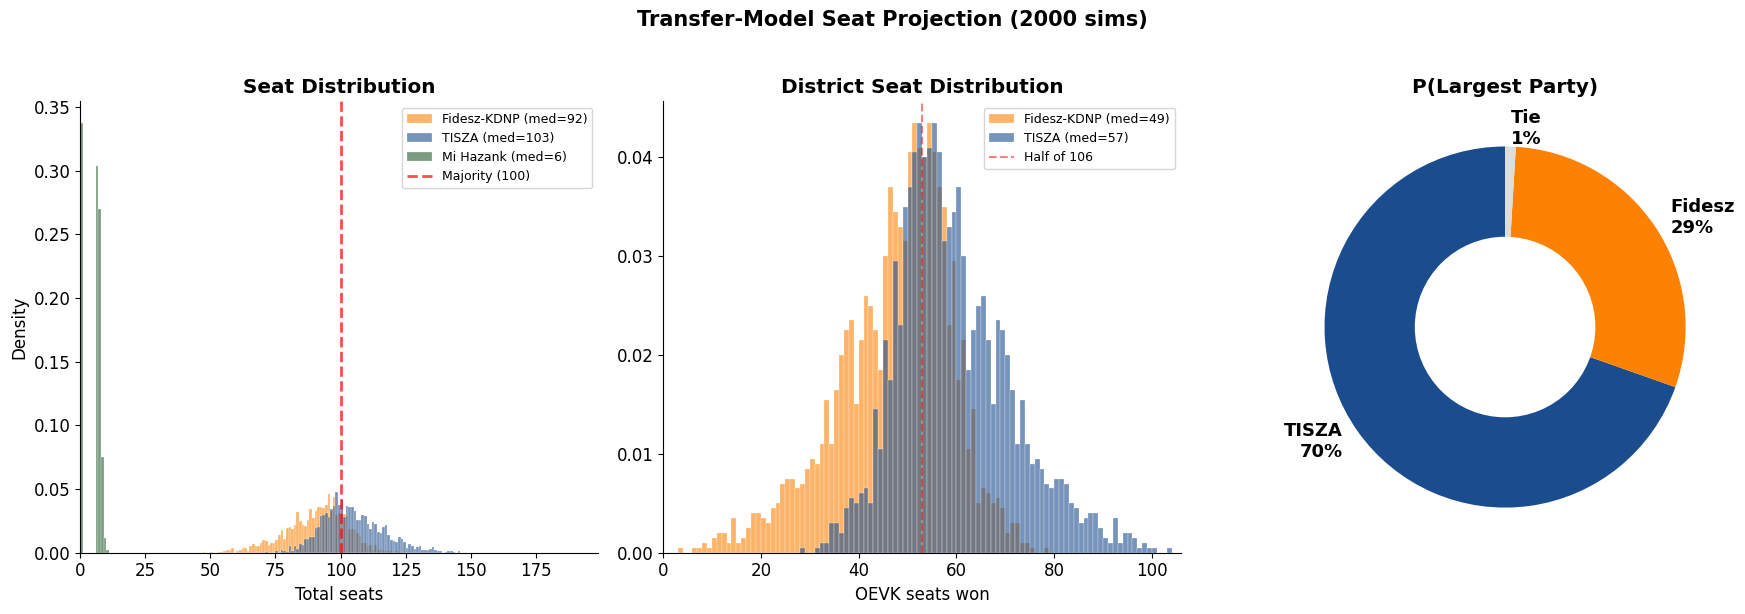

In [24]:
COLORS = {
    "Fidesz-KDNP": "#fd8204",
    "TISZA": "#1B4D8E",
    "Baloldal": "#e6331a",
    "Mi Hazank": "#215b2c",
    "MKKP": "#888888",
    "Other": "#aaaaaa",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Total seat histograms
ax = axes[0]
for p in ["Fidesz-KDNP", "TISZA", "Mi Hazank"]:
    ax.hist(total_seats_all[p], bins=range(0, 200), alpha=0.6,
            color=COLORS[p], label=f"{p} (med={np.median(total_seats_all[p]):.0f})",
            density=True, edgecolor="white", linewidth=0.3)
ax.axvline(100, color="red", linestyle="--", linewidth=2, alpha=0.7, label="Majority (100)")
ax.set_xlabel("Total seats")
ax.set_ylabel("Density")
ax.set_title("Seat Distribution", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 199)

# 2. OEVK seat distribution
ax2 = axes[1]
for p in ["Fidesz-KDNP", "TISZA"]:
    ax2.hist(oevk_seats_all[p], bins=range(0, 107), alpha=0.6,
             color=COLORS[p], label=f"{p} (med={np.median(oevk_seats_all[p]):.0f})",
             density=True, edgecolor="white", linewidth=0.3)
ax2.axvline(53, color="red", linestyle="--", linewidth=1.5, alpha=0.5, label="Half of 106")
ax2.set_xlabel("OEVK seats won")
ax2.set_title("District Seat Distribution", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_xlim(0, 106)

# 3. Win probability donut
ax3 = axes[2]
sizes = [tisza_largest, fidesz_largest, 100 - tisza_largest - fidesz_largest]
labels_pie = [f"TISZA\n{tisza_largest:.0f}%", f"Fidesz\n{fidesz_largest:.0f}%", f"Tie\n{100-tisza_largest-fidesz_largest:.0f}%"]
colors_pie = [COLORS["TISZA"], COLORS["Fidesz-KDNP"], "#dddddd"]
wedges, texts = ax3.pie(
    [max(s, 0.1) for s in sizes], labels=labels_pie, colors=colors_pie,
    startangle=90, textprops={"fontsize": 13, "fontweight": "bold"},
)
centre = plt.Circle((0, 0), 0.5, fc="white")
ax3.add_artist(centre)
ax3.set_title("P(Largest Party)", fontweight="bold")

plt.suptitle(f"Transfer-Model Seat Projection ({N_SIM} sims)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# District-level win frequencies
district_wins = {p: np.zeros(D) for p in MAIN_PARTIES}

for r in sim_results:
    for d_idx, dist in enumerate(districts):
        winner = r["district_seats"].get(dist, "")
        if winner in district_wins:
            district_wins[winner][d_idx] += 1

for p in MAIN_PARTIES:
    district_wins[p] /= N_SIM

# Competitive districts (neither party wins > 90% of simulations)
competitive = []
for d_idx, dist in enumerate(districts):
    max_win_rate = max(district_wins[p][d_idx] for p in MAIN_PARTIES)
    if max_win_rate < 0.90:
        fidesz_rate = district_wins["Fidesz-KDNP"][d_idx]
        tisza_rate = district_wins["TISZA"][d_idx]
        competitive.append((dist, fidesz_rate, tisza_rate))

competitive.sort(key=lambda x: abs(x[1] - x[2]))

print(f"Competitive districts ({len(competitive)} where no party wins >90% of sims):")
print(f"  {'District':>10s}  {'Fidesz':>8s}  {'TISZA':>8s}  {'Gap':>6s}")
print("  " + "-" * 36)
for dist, f_rate, t_rate in competitive[:25]:
    print(f"  {dist:>10s}  {f_rate:>7.0%}  {t_rate:>7.0%}  {abs(f_rate - t_rate):>5.0%}")

Competitive districts (30 where no party wins >90% of sims):
    District    Fidesz     TISZA     Gap
  ------------------------------------
        15-2      49%      51%     3%
        05-6      52%      48%     5%
        17-1      47%      53%     6%
        05-4      46%      54%     8%
        14-4      55%      45%    10%
        04-3      60%      40%    19%
        12-3      60%      40%    20%
        10-2      39%      61%    22%
        15-3      62%      38%    24%
        03-2      37%      63%    26%
        15-4      64%      36%    29%
        13-1      32%      68%    37%
        08-4      73%      27%    47%
        03-6      74%      26%    48%
        06-3      75%      25%    50%
        07-3      76%      24%    52%
       14-11      76%      24%    53%
        11-2      78%      22%    56%
        16-2      80%      20%    60%
        10-1      20%      80%    60%
        20-1      80%      20%    61%
        07-2      81%      19%    63%
        20-3      18%  

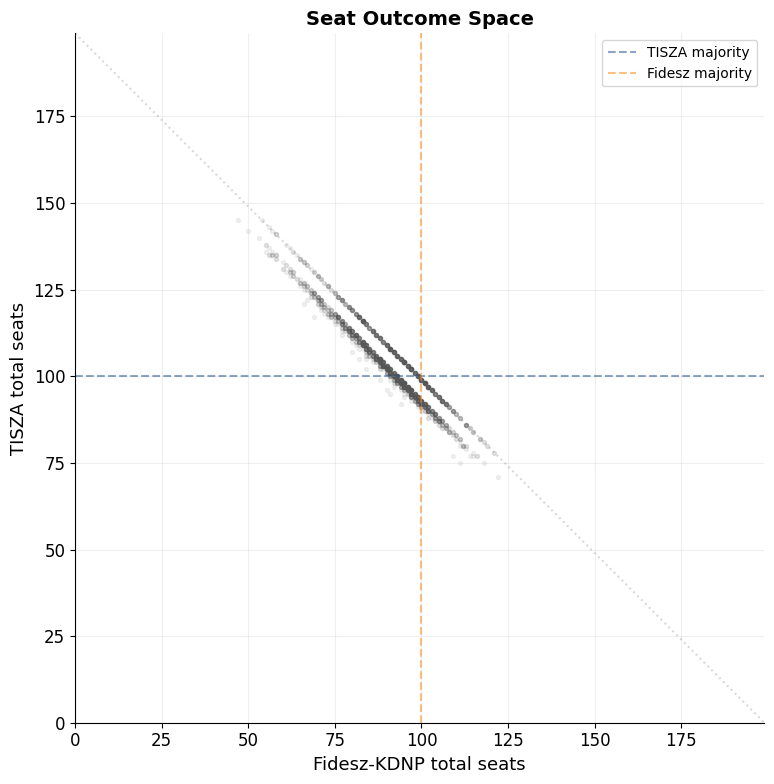

In [26]:
# Seat scatter: Fidesz vs TISZA total seats per simulation
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(fidesz_total, tisza_total, alpha=0.08, s=8, color="#555555")
ax.axhline(100, color=COLORS["TISZA"], linestyle="--", alpha=0.5, label="TISZA majority")
ax.axvline(100, color=COLORS["Fidesz-KDNP"], linestyle="--", alpha=0.5, label="Fidesz majority")
ax.plot([0, 199], [199, 0], color="grey", linestyle=":", alpha=0.3)

ax.set_xlabel("Fidesz-KDNP total seats", fontsize=13)
ax.set_ylabel("TISZA total seats", fontsize=13)
ax.set_title("Seat Outcome Space", fontweight="bold", fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, 199)
ax.set_ylim(0, 199)
ax.set_aspect("equal")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Transfer matrix visualization

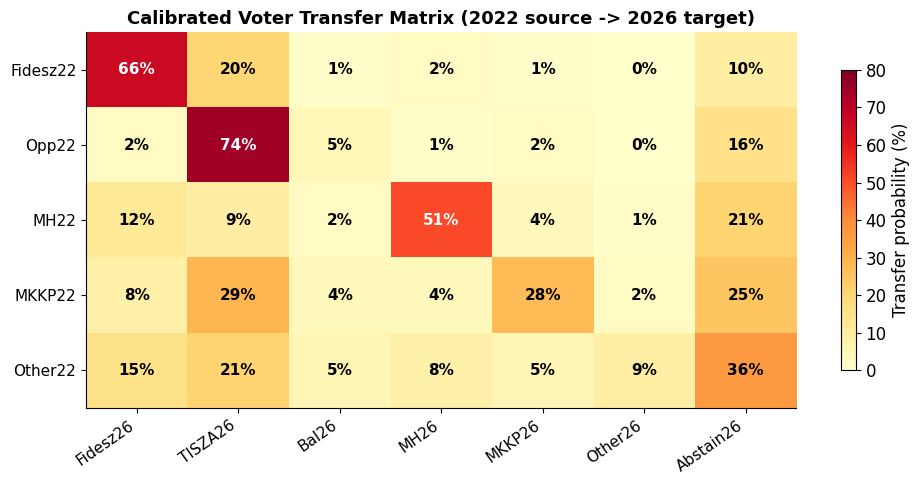

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(Q_cal * 100, cmap="YlOrRd", aspect="auto", vmin=0, vmax=80)

ax.set_xticks(range(T))
ax.set_yticks(range(S))
ax.set_xticklabels(TARGETS, rotation=35, ha="right", fontsize=11)
ax.set_yticklabels(SOURCES, fontsize=11)

for i in range(S):
    for j in range(T):
        val = Q_cal[i, j] * 100
        color = "white" if val > 40 else "black"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Transfer probability (%)")
ax.set_title("Calibrated Voter Transfer Matrix (2022 source -> 2026 target)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 8b. Prior-only backtest (no nowcast calibration)

What does the model predict if we use `Q_PRIOR` directly — i.e. skip the
calibration step that pulls Q toward the current polling nowcast?

This uses a very large `lam_prior` (1e8) so the KL penalty dominates
and the optimizer effectively leaves Q at the prior.

In [28]:
prior_only = run_pipeline(
    V22, districts, nowcast_shares, nowcast_se,
    q_prior=Q_PRIOR,
    sigma_district=SIGMA_DISTRICT,
    conc_national=CONC_NATIONAL,
    lam_prior=1e8,
    n_sim=1000,
    seed=2026,
)

print("=" * 60)
print("  PRIOR-ONLY (no nowcast calibration)")
print("=" * 60)
print(f"  P(TISZA largest party):     {prior_only['p_tisza_largest']*100:>6.1f}%")
print(f"  P(TISZA majority ≥100):     {prior_only['p_tisza_majority']*100:>6.1f}%")
print(f"  P(Fidesz largest party):    {prior_only['p_fidesz_largest']*100:>6.1f}%")
print(f"  P(Fidesz majority ≥100):    {prior_only['p_fidesz_majority']*100:>6.1f}%")
print(f"  Median TISZA seats:         {prior_only['median_tisza_seats']:>6.0f}")
print(f"  Median Fidesz seats:        {prior_only['median_fidesz_seats']:>6.0f}")
print("=" * 60)
print()
print("Recall the prior implies: Fidesz26 ~52.9%, TISZA26 ~31.0%")
print("vs nowcast:               Fidesz26 ~39.6%, TISZA26 ~47.3%")

NameError: name 'run_pipeline' is not defined

## 8c. 2022 replay with noise (no transfers)

Backtest the district noise model by adding logistic-normal perturbations
directly to the actual 2022 district-level vote counts (bypassing the
transfer matrix entirely). Each draw perturbs per-district vote shares
in log-space with `sigma_district`, resamples integer counts via
multinomial, then feeds into `seat_calculator` with the real 2022
party names and thresholds.

Sanity check: the actual 2022 seat outcome (Fidesz 135, Opposition 56)
should fall within the simulated distribution.

In [ ]:
def replay_2022(baseline, sigma, n_sim, seed):
    """Replay 2022 with logistic-normal district noise, no transfer matrix."""
    _rng = np.random.default_rng(seed)
    oevk = baseline["oevk_votes"]
    dists = sorted(oevk.keys())
    results = []
    for _ in range(n_sim):
        noisy_oevk = {}
        for dist in dists:
            parties = list(oevk[dist].keys())
            votes = np.array([oevk[dist][p] for p in parties], dtype=float)
            total = int(votes.sum())
            log_shares = np.log(votes / votes.sum() + 1e-10)
            log_shares += _rng.normal(0, sigma, size=len(parties))
            noisy_shares = softmax(log_shares)
            noisy_votes = _rng.multinomial(total, noisy_shares)
            noisy_oevk[dist] = {p: int(v) for p, v in zip(parties, noisy_votes)}
        result = seat_calculator(
            oevk_votes=noisy_oevk,
            direct_list_votes=baseline["direct_list_votes"],
            list_meta=baseline["list_meta"],
        )
        results.append(result)
    return results


N_SIM_REPLAY = 2000
replay_results = replay_2022(baseline, sigma=SIGMA_DISTRICT, n_sim=N_SIM_REPLAY, seed=2022)

replay_fidesz = np.array([r["total_seats"].get(FIDESZ, 0) for r in replay_results])
replay_opp = np.array([r["total_seats"].get(EEGY, 0) for r in replay_results])

print("=" * 60)
print("  2022 REPLAY (direct noise, no transfer matrix)")
print("=" * 60)
print(f"  Fidesz median seats:   {np.median(replay_fidesz):>6.0f}  (actual 2022: 135)")
print(f"  Fidesz 5th–95th:       {np.percentile(replay_fidesz, 5):>3.0f} – {np.percentile(replay_fidesz, 95):>3.0f}")
print(f"  Opp median seats:      {np.median(replay_opp):>6.0f}  (actual 2022:  56)")
print(f"  Opp 5th–95th:          {np.percentile(replay_opp, 5):>3.0f} – {np.percentile(replay_opp, 95):>3.0f}")
print(f"  P(Fidesz largest):     {(replay_fidesz > replay_opp).mean()*100:>6.1f}%")
print(f"  P(Fidesz majority):    {(replay_fidesz >= 100).mean()*100:>6.1f}%")
print(f"  P(Fidesz supermaj):    {(replay_fidesz >= 133).mean()*100:>6.1f}%")
print("=" * 60)

  2022 REPLAY (direct noise, no transfer matrix)
  Fidesz median seats:      132  (actual 2022: 135)
  Fidesz 5th–95th:       127 – 136
  Opp median seats:          60  (actual 2022:  56)
  Opp 5th–95th:           56 –  65
  P(Fidesz largest):      100.0%
  P(Fidesz majority):     100.0%
  P(Fidesz supermaj):      38.5%


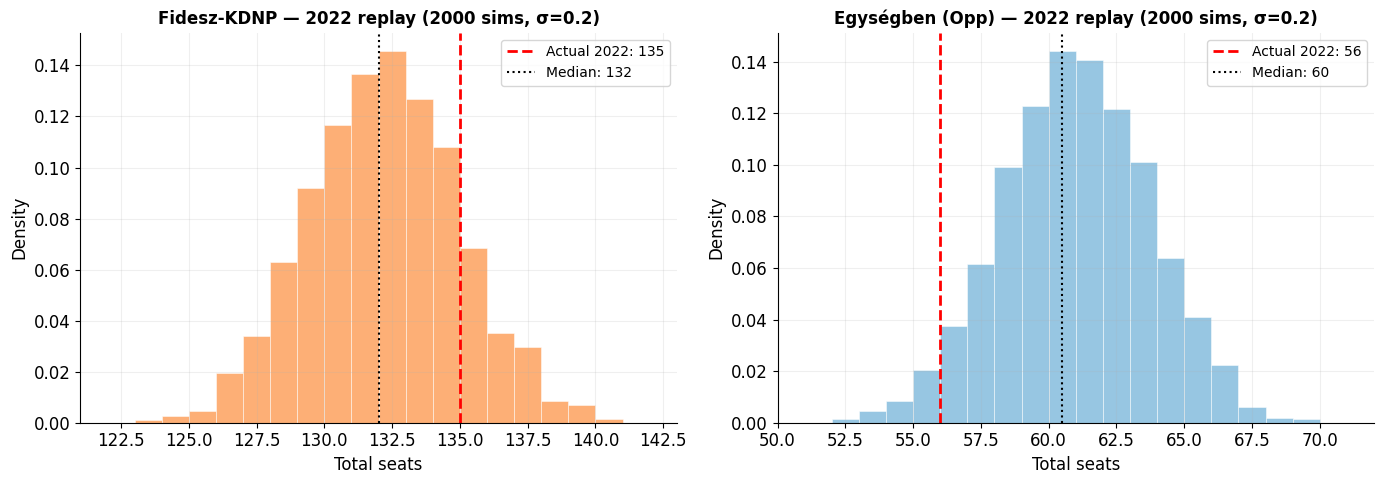

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, actual, color in [
    (axes[0], replay_fidesz, "Fidesz-KDNP", 135, "#fd8d3c"),
    (axes[1], replay_opp, "Egységben (Opp)", 56, "#6baed6"),
]:
    ax.hist(data, bins=range(int(data.min()) - 1, int(data.max()) + 3),
            density=True, alpha=0.7, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(actual, color="red", linewidth=2, linestyle="--", label=f"Actual 2022: {actual}")
    ax.axvline(np.median(data), color="black", linewidth=1.5, linestyle=":", label=f"Median: {np.median(data):.0f}")
    ax.set_xlabel("Total seats", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(f"{label} — 2022 replay ({N_SIM_REPLAY} sims, σ={SIGMA_DISTRICT})",
                 fontweight="bold", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
jbgfdj

## 9. Sensitivity Analysis

Sweep key hyperparameters one at a time and track `P(TISZA largest party)`.

In [ ]:
def make_q_prior_fidesz_retention(base_q, retention):
    """Return a copy of base_q with row 0 col 0 set to `retention`.

    The delta is redistributed proportionally across the other columns
    of row 0 so the row still sums to 1.
    """
    q = base_q.copy()
    old = q[0, 0]
    if retention == old:
        return q
    remainder_old = 1.0 - old
    remainder_new = 1.0 - retention
    if remainder_old > 0:
        scale = remainder_new / remainder_old
    else:
        scale = 0.0
    q[0, 1:] *= scale
    q[0, 0] = retention
    q[0] /= q[0].sum()
    return q


def run_pipeline(
    V22,
    districts,
    nowcast_shares,
    nowcast_se,
    q_prior=None,
    sigma_district=0.15,
    conc_national=80.0,
    lam_prior=5.0,
    n_sim=2000,
    seed=2026,
):
    """End-to-end pipeline: calibrate Q then run MC seat simulation.

    Returns dict with outcome probabilities and median seat counts.
    """
    if q_prior is None:
        q_prior = Q_PRIOR

    _rng = np.random.default_rng(seed)

    log_prior = np.log(q_prior + 1e-10)
    x0 = (log_prior[:, :-1] - log_prior[:, -1:]).flatten()

    res = minimize(
        objective, x0,
        args=(V22, nowcast_shares, nowcast_se, q_prior, S, T, TARGETS, lam_prior),
        method="L-BFGS-B",
        options={"maxiter": 5000, "ftol": 1e-12},
    )
    q_cal = q_from_unconstrained(res.x, S, T)

    fidesz_seats = np.zeros(n_sim)
    tisza_seats = np.zeros(n_sim)

    for i in range(n_sim):
        result = run_one_sim(V22, q_cal, districts, _rng,
                             sigma=sigma_district, conc=conc_national)
        fidesz_seats[i] = result["total_seats"].get("Fidesz-KDNP", 0)
        tisza_seats[i] = result["total_seats"].get("TISZA", 0)

    return {
        "p_tisza_largest": float((tisza_seats > fidesz_seats).mean()),
        "p_tisza_majority": float((tisza_seats >= 100).mean()),
        "p_fidesz_largest": float((fidesz_seats > tisza_seats).mean()),
        "p_fidesz_majority": float((fidesz_seats >= 100).mean()),
        "median_tisza_seats": float(np.median(tisza_seats)),
        "median_fidesz_seats": float(np.median(fidesz_seats)),
    }

print("run_pipeline() and make_q_prior_fidesz_retention() defined.")

run_pipeline() and make_q_prior_fidesz_retention() defined.


In [ ]:
N_SIM_SWEEP = 1000

SWEEP_SIGMA   = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]
SWEEP_CONC    = [20, 40, 60, 80, 100, 150, 200, 400]
SWEEP_LAM     = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
SWEEP_FIDESZ  = [0.65, 0.70, 0.75, 0.80, 0.82, 0.85, 0.88, 0.90]

BASELINE = dict(sigma_district=0.15, conc_national=80.0, lam_prior=5.0)

def _sweep(param_name, values, extra_kw=None):
    """Run run_pipeline over a list of values for one hyperparameter."""
    results = []
    for v in values:
        kw = {**BASELINE, "n_sim": N_SIM_SWEEP}
        if extra_kw:
            kw.update(extra_kw(v))
        else:
            kw[param_name] = v
        print(f"  {param_name}={v} ...", end=" ", flush=True)
        r = run_pipeline(V22, districts, nowcast_shares, nowcast_se, **kw)
        print(f"P(TISZA largest)={r['p_tisza_largest']:.3f}")
        results.append((v, r))
    return results

print("=== Sweep: sigma_district ===")
sweep_sigma_results = _sweep("sigma_district", SWEEP_SIGMA)

print("\n=== Sweep: conc_national ===")
sweep_conc_results = _sweep("conc_national", SWEEP_CONC)

print("\n=== Sweep: lam_prior ===")
sweep_lam_results = _sweep("lam_prior", SWEEP_LAM)

print("\n=== Sweep: Fidesz retention ===")
sweep_fidesz_results = _sweep(
    "fidesz_retention", SWEEP_FIDESZ,
    extra_kw=lambda v: {"q_prior": make_q_prior_fidesz_retention(Q_PRIOR, v)},
)

print("\nAll sweeps done.")

=== Sweep: sigma_district ===
  sigma_district=0.05 ... P(TISZA largest)=0.838
  sigma_district=0.08 ... 

KeyboardInterrupt: 

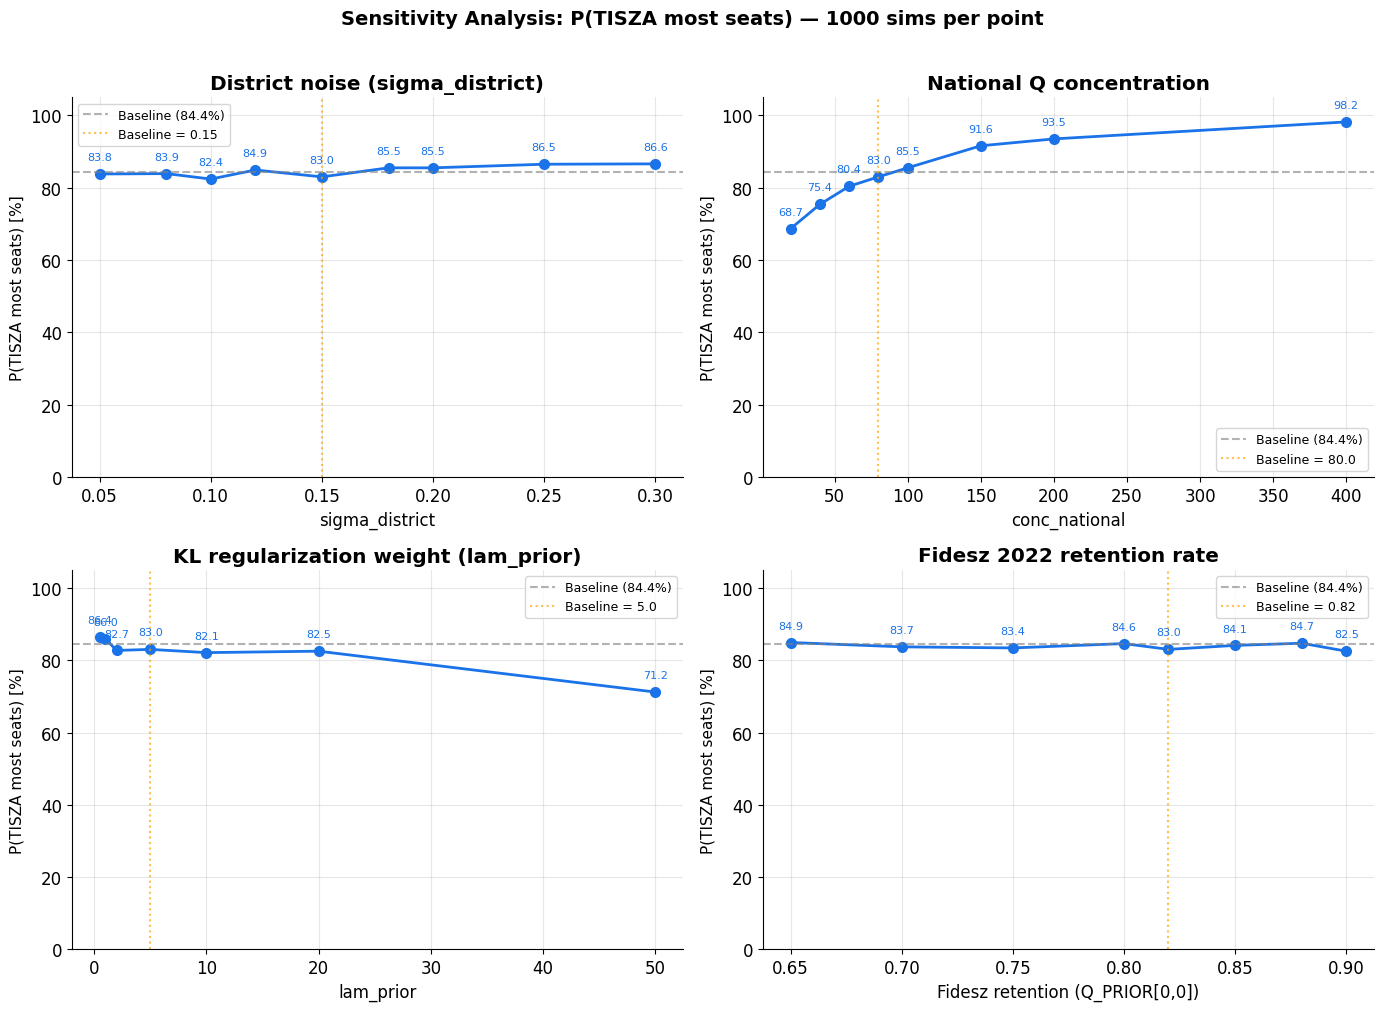

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def _plot_sweep(ax, sweep_results, xlabel, baseline_val):
    xs = [v for v, _ in sweep_results]
    ys = [r["p_tisza_largest"] * 100 for _, r in sweep_results]
    ax.plot(xs, ys, "o-", color="#1a73e8", linewidth=2, markersize=7)
    ax.axhline(y=84.4, color="gray", linestyle="--", alpha=0.6, label="Baseline (84.4%)")
    ax.axvline(x=baseline_val, color="orange", linestyle=":", alpha=0.7, label=f"Baseline = {baseline_val}")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("P(TISZA most seats) [%]", fontsize=11)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    for x, y in zip(xs, ys):
        ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=8, color="#1a73e8")

_plot_sweep(axes[0, 0], sweep_sigma_results, "sigma_district", 0.15)
axes[0, 0].set_title("District noise (sigma_district)", fontweight="bold")

_plot_sweep(axes[0, 1], sweep_conc_results, "conc_national", 80.0)
axes[0, 1].set_title("National Q concentration", fontweight="bold")

_plot_sweep(axes[1, 0], sweep_lam_results, "lam_prior", 5.0)
axes[1, 0].set_title("KL regularization weight (lam_prior)", fontweight="bold")

_plot_sweep(axes[1, 1], sweep_fidesz_results, "Fidesz retention (Q_PRIOR[0,0])", 0.82)
axes[1, 1].set_title("Fidesz 2022 retention rate", fontweight="bold")

fig.suptitle(f"Sensitivity Analysis: P(TISZA most seats) — {N_SIM_SWEEP} sims per point",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()